In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("50_Startups.csv")

In [3]:
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
dataset=pd.get_dummies(dataset,drop_first=True)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False
5,131876.90,99814.71,362861.36,156991.12,False,True
6,134615.46,147198.87,127716.82,156122.51,False,False
7,130298.13,145530.06,323876.68,155752.60,True,False
8,120542.52,148718.95,311613.29,152211.77,False,True
9,123334.88,108679.17,304981.62,149759.96,False,False


In [6]:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [7]:
Independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend', 
       'State_Florida', 'State_New York']]

In [8]:
Dependent=dataset[["Profit"]]

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(Independent,Dependent,test_size=0.30,random_state=0)

In [10]:
from sklearn.tree import DecisionTreeRegressor
Regressor=DecisionTreeRegressor(criterion="absolute_error",splitter="best")
Regressor=Regressor.fit(x_train,y_train)

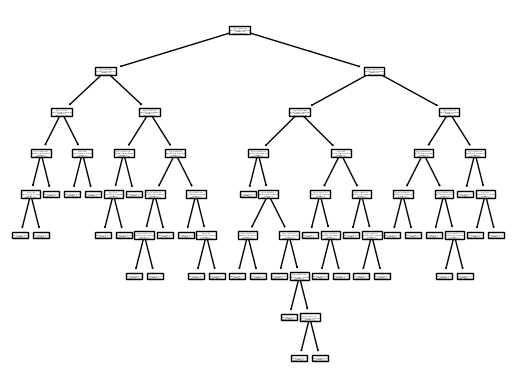

In [11]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(Regressor)
plt.show()

In [12]:
y_pred=Regressor.predict(x_test)

In [13]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)

In [14]:
r_score

0.9553642057438022

In [15]:
import pickle
filename="finalized_model_Tree.sav"

In [16]:
pickle.dump(Regressor,open(filename,'wb'))

In [17]:
loaded_model=pickle.load(open("finalized_model_Tree.sav",'rb'))
result=loaded_model.predict([[13345,45123,78345,True,False]])

C:\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [18]:
result

array([71498.49])